In [1]:
# Task 3: Cuisine Classification
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Dataset .csv")

# Basic info
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

# Look at cuisines
df = df.dropna(subset=['Cuisines'])
df['Cuisine_Primary'] = df['Cuisines'].apply(lambda x: x.split(',')[0].strip())

print("\nTop 15 cuisines:")
print(df['Cuisine_Primary'].value_counts().head(15))
print(f"\nTotal unique cuisines: {df['Cuisine_Primary'].nunique()}")

Shape: (9551, 21)

Missing values:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Top 15 cuisines:
Cuisine_Primary
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Name: count, dtype: int64

Total unique cuisines: 119


In [2]:
# Step 2: Preprocessing

# Keep only top 10 cuisines
top_cuisines = df['Cuisine_Primary'].value_counts().head(10).index.tolist()
print("Top 10 cuisines we'll classify:")
for i, c in enumerate(top_cuisines, 1):
    print(f"  {i}. {c}")

# Filter dataset to only these cuisines
df_filtered = df[df['Cuisine_Primary'].isin(top_cuisines)].copy()
print(f"\nDataset size after filtering: {df_filtered.shape}")

# Drop columns we don't need
cols_to_drop = ['Restaurant ID', 'Restaurant Name', 'Address',
                'Locality', 'Locality Verbose', 'Currency',
                'Rating color', 'Rating text', 'Cuisines']
df_filtered = df_filtered.drop(columns=cols_to_drop)

# Encode Yes/No columns
yes_no_cols = ['Has Table booking', 'Has Online delivery',
               'Is delivering now', 'Switch to order menu']
for col in yes_no_cols:
    df_filtered[col] = df_filtered[col].map({'Yes': 1, 'No': 0})

# Encode City
from sklearn.preprocessing import LabelEncoder
le_city = LabelEncoder()
df_filtered['City'] = le_city.fit_transform(df_filtered['City'])

# Encode target (Cuisine_Primary) into numbers
le_cuisine = LabelEncoder()
df_filtered['Cuisine_Label'] = le_cuisine.fit_transform(df_filtered['Cuisine_Primary'])

print("\nCuisine labels mapping:")
for i, cuisine in enumerate(le_cuisine.classes_):
    print(f"  {i} → {cuisine}")

print("\nCleaned data shape:", df_filtered.shape)
print(df_filtered.head(3))

Top 10 cuisines we'll classify:
  1. North Indian
  2. Chinese
  3. Fast Food
  4. Bakery
  5. Cafe
  6. American
  7. South Indian
  8. Mithai
  9. Street Food
  10. Continental

Dataset size after filtering: (7014, 22)

Cuisine labels mapping:
  0 → American
  1 → Bakery
  2 → Cafe
  3 → Chinese
  4 → Continental
  5 → Fast Food
  6 → Mithai
  7 → North Indian
  8 → South Indian
  9 → Street Food

Cleaned data shape: (7014, 14)
    Country Code  City   Longitude   Latitude  Average Cost for two  \
5            162    59  121.056314  14.583764                  1000   
11           162    71  121.060820  14.570849                   900   
15           162    84  121.057040  14.237082                   800   

    Has Table booking  Has Online delivery  Is delivering now  \
5                   0                    0                  0   
11                  1                    0                  0   
15                  0                    0                  0   

    Switch to order 

In [4]:
# Step 3: Split data and train models
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Separate features and target
X = df_filtered.drop(columns=['Cuisine_Primary', 'Cuisine_Label'])
y = df_filtered['Cuisine_Label']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")
print(f"Features used: {X.columns.tolist()}")

# --- Model 1: Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

# --- Model 2: Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# --- Compare ---
print("\n" + "="*45)
print("MODEL COMPARISON")
print("="*45)
print(f"\n📊 Logistic Regression Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(f"🌳 Random Forest Accuracy:       {accuracy_score(y_test, rf_preds):.4f}")

Training set: (5611, 12)
Testing set:  (1403, 12)
Features used: ['Country Code', 'City', 'Longitude', 'Latitude', 'Average Cost for two', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Votes']


c:\Users\sures\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



MODEL COMPARISON

📊 Logistic Regression Accuracy: 0.4547
🌳 Random Forest Accuracy:       0.4512


🌳 RANDOM FOREST - Detailed Report
              precision    recall  f1-score   support

    American       0.61      0.65      0.63        48
      Bakery       0.28      0.23      0.26       115
        Cafe       0.42      0.29      0.34       127
     Chinese       0.24      0.12      0.16       165
 Continental       0.21      0.08      0.12        50
   Fast Food       0.22      0.14      0.17       137
      Mithai       0.33      0.34      0.34        56
North Indian       0.53      0.77      0.63       598
South Indian       0.00      0.00      0.00        57
 Street Food       0.33      0.28      0.30        50

    accuracy                           0.45      1403
   macro avg       0.32      0.29      0.29      1403
weighted avg       0.39      0.45      0.41      1403



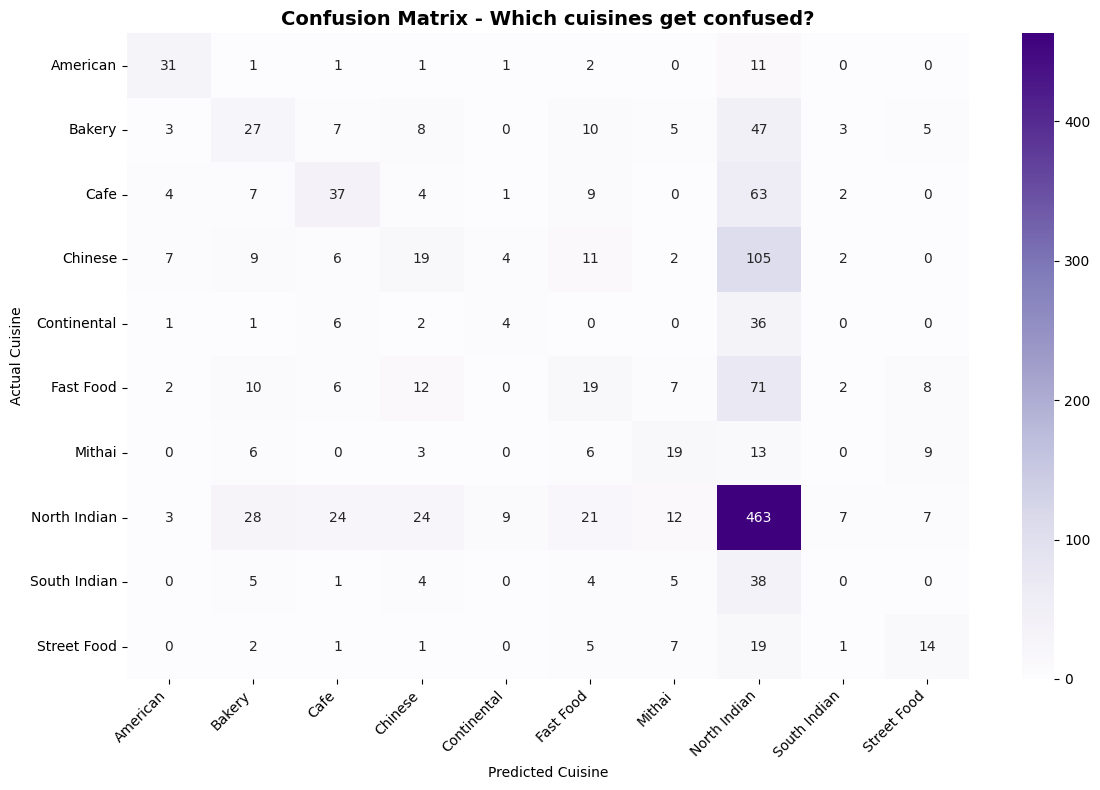


🔍 Feature Importance:
             Feature  Importance
           Longitude    0.229361
            Latitude    0.228907
               Votes    0.170678
Average Cost for two    0.138943
    Aggregate rating    0.116607
                City    0.045550
         Price range    0.025720
 Has Online delivery    0.019850
        Country Code    0.014131
   Has Table booking    0.008681
   Is delivering now    0.001571
Switch to order menu    0.000000


In [5]:
# Step 4: Detailed evaluation
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Use Random Forest (slightly better)
print("🌳 RANDOM FOREST - Detailed Report")
print("="*55)
print(classification_report(y_test, rf_preds, 
      target_names=le_cuisine.classes_))

# Confusion Matrix
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le_cuisine.classes_,
            yticklabels=le_cuisine.classes_)
plt.title('Confusion Matrix - Which cuisines get confused?', 
          fontsize=14, fontweight='bold')
plt.ylabel('Actual Cuisine')
plt.xlabel('Predicted Cuisine')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Feature Importance
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n🔍 Feature Importance:")
print(importances.to_string(index=False))

In [8]:
import json

report_data = {
    'American':    {'precision': 0.61, 'recall': 0.65, 'f1': 0.63, 'support': 48,  'emoji': '🍔'},
    'Bakery':      {'precision': 0.28, 'recall': 0.23, 'f1': 0.26, 'support': 115, 'emoji': '🥐'},
    'Cafe':        {'precision': 0.42, 'recall': 0.29, 'f1': 0.34, 'support': 127, 'emoji': '☕'},
    'Chinese':     {'precision': 0.24, 'recall': 0.12, 'f1': 0.16, 'support': 165, 'emoji': '🥢'},
    'Continental': {'precision': 0.21, 'recall': 0.08, 'f1': 0.12, 'support': 50,  'emoji': '🍽️'},
    'Fast Food':   {'precision': 0.22, 'recall': 0.14, 'f1': 0.17, 'support': 137, 'emoji': '🍟'},
    'Mithai':      {'precision': 0.33, 'recall': 0.34, 'f1': 0.34, 'support': 56,  'emoji': '🍬'},
    'North Indian':{'precision': 0.53, 'recall': 0.77, 'f1': 0.63, 'support': 598, 'emoji': '🍛'},
    'South Indian':{'precision': 0.00, 'recall': 0.00, 'f1': 0.00, 'support': 57,  'emoji': '🥘'},
    'Street Food': {'precision': 0.33, 'recall': 0.28, 'f1': 0.30, 'support': 50,  'emoji': '🌮'},
}

feature_imp = {
    'Longitude': 0.229, 'Latitude': 0.229, 'Votes': 0.171,
    'Avg Cost': 0.139, 'Rating': 0.117, 'City': 0.046,
    'Price range': 0.026, 'Online Delivery': 0.020,
    'Country Code': 0.014, 'Table Booking': 0.009
}

def get_grade(f1):
    if f1 >= 0.6: return ('A', '#16a34a')
    elif f1 >= 0.4: return ('B', '#ca8a04')
    elif f1 >= 0.2: return ('C', '#ea580c')
    else: return ('F', '#dc2626')

cards_html = ""
for cuisine, data in report_data.items():
    grade, color = get_grade(data['f1'])
    bar_w = int(data['f1'] * 100)
    p_bar = int(data['precision'] * 100)
    r_bar = int(data['recall'] * 100)
    cards_html += f"""
    <div class="cuisine-card" style="animation-delay:{list(report_data.keys()).index(cuisine)*0.1}s">
      <div class="card-header">
        <span class="emoji">{data['emoji']}</span>
        <div>
          <div class="cuisine-name">{cuisine}</div>
          <div class="support">{data['support']} restaurants</div>
        </div>
        <div class="grade" style="background:{color}">{grade}</div>
      </div>
      <div class="metric-row">
        <span class="metric-label">F1 Score</span>
        <div class="bar-bg"><div class="bar-fill" style="width:{bar_w}%;background:{color}"></div></div>
        <span class="metric-val">{data['f1']:.2f}</span>
      </div>
      <div class="metric-row">
        <span class="metric-label">Precision</span>
        <div class="bar-bg"><div class="bar-fill" style="width:{p_bar}%;background:#6366f1"></div></div>
        <span class="metric-val">{data['precision']:.2f}</span>
      </div>
      <div class="metric-row">
        <span class="metric-label">Recall</span>
        <div class="bar-bg"><div class="bar-fill" style="width:{r_bar}%;background:#0891b2"></div></div>
        <span class="metric-val">{data['recall']:.2f}</span>
      </div>
    </div>"""

html = """<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Cuisine Classification | Cognifyz Task 3</title>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<style>
* { margin:0; padding:0; box-sizing:border-box; }
body { font-family:'Segoe UI',sans-serif; background:#f8fafc; color:#1e293b; }

.header {
  background: linear-gradient(135deg,#1e293b,#334155);
  padding: 50px 40px; text-align:center;
}
.header h1 { font-size:2.5rem; font-weight:800; color:white; margin-bottom:10px; }
.header p { color:rgba(255,255,255,0.7); font-size:1rem; }

.stats-row {
  display:flex; gap:16px; padding:30px 40px;
  justify-content:center; flex-wrap:wrap;
  background:white; border-bottom:1px solid #e2e8f0;
}
.stat-card {
  text-align:center; padding:20px 28px;
  border-radius:12px; min-width:140px;
  border:1px solid #e2e8f0;
  background:white;
  box-shadow:0 2px 8px rgba(0,0,0,0.05);
}
.stat-card .value { font-size:1.8rem; font-weight:800; }
.stat-card .label { font-size:0.8rem; color:#64748b; margin-top:4px; }

.ml-info { background:#f1f5f9; padding:16px 40px; text-align:center; border-bottom:1px solid #e2e8f0; }
.ml-badge {
  background:#1e293b; color:white;
  padding:5px 14px; border-radius:999px;
  font-size:0.78rem; font-weight:600;
  display:inline-block; margin:3px;
}

.section { padding:32px 40px; }
.section-title {
  font-size:1.2rem; font-weight:700; color:#1e293b;
  margin-bottom:20px; padding-bottom:10px;
  border-bottom:2px solid #e2e8f0;
  display:flex; align-items:center; gap:8px;
}

/* Cuisine Cards */
.cards-grid {
  display:grid;
  grid-template-columns:repeat(auto-fill,minmax(280px,1fr));
  gap:20px;
}
.cuisine-card {
  background:white; border-radius:16px;
  padding:20px; border:1px solid #e2e8f0;
  box-shadow:0 2px 12px rgba(0,0,0,0.06);
  animation: slideUp 0.5s ease forwards;
  opacity:0; transform:translateY(20px);
}
@keyframes slideUp {
  to { opacity:1; transform:translateY(0); }
}
.card-header {
  display:flex; align-items:center;
  gap:12px; margin-bottom:16px;
}
.emoji { font-size:2rem; }
.cuisine-name { font-size:1rem; font-weight:700; color:#1e293b; }
.support { font-size:0.78rem; color:#94a3b8; margin-top:2px; }
.grade {
  margin-left:auto; width:36px; height:36px;
  border-radius:50%; display:flex;
  align-items:center; justify-content:center;
  font-weight:800; font-size:0.9rem; color:white;
}
.metric-row {
  display:flex; align-items:center;
  gap:8px; margin-bottom:10px;
}
.metric-label { font-size:0.75rem; color:#64748b; width:65px; flex-shrink:0; }
.bar-bg { flex:1; background:#f1f5f9; border-radius:999px; height:8px; overflow:hidden; }
.bar-fill {
  height:100%; border-radius:999px;
  transition:width 1.5s ease;
  width:0%;
}
.metric-val { font-size:0.78rem; font-weight:700; color:#1e293b; width:30px; text-align:right; }

/* Charts */
.charts-row { display:grid; grid-template-columns:1fr 1fr; gap:24px; }
.chart-card {
  background:white; border-radius:16px;
  padding:24px; border:1px solid #e2e8f0;
  box-shadow:0 2px 12px rgba(0,0,0,0.06);
}
.chart-card h3 {
  font-size:0.9rem; font-weight:700; color:#475569;
  margin-bottom:16px; text-transform:uppercase;
  letter-spacing:0.06em;
}
canvas { max-height:260px; }

/* Insights */
.insights-row { display:grid; grid-template-columns:1fr 1fr 1fr; gap:16px; }
.insight-card {
  background:white; border-radius:12px;
  padding:18px; border:1px solid #e2e8f0;
  box-shadow:0 2px 8px rgba(0,0,0,0.04);
}
.insight-icon { font-size:1.5rem; margin-bottom:8px; }
.insight-title { font-size:0.8rem; font-weight:700; color:#64748b; text-transform:uppercase; letter-spacing:0.05em; margin-bottom:6px; }
.insight-text { font-size:0.88rem; color:#475569; line-height:1.5; }
.highlight { color:#16a34a; font-weight:700; }
.warning { color:#dc2626; font-weight:700; }

.footer {
  text-align:center; padding:24px;
  color:#94a3b8; font-size:0.82rem;
  border-top:1px solid #e2e8f0;
  background:white; margin-top:10px;
}
</style>
</head>
<body>

<div class="header">
  <h1>🍜 Cuisine Classification Model</h1>
  <p>Random Forest Classifier &nbsp;|&nbsp; Cognifyz Internship Task 3 &nbsp;|&nbsp; Zomato Dataset</p>
</div>

<div class="stats-row">
  <div class="stat-card">
    <div class="value" style="color:#1e293b">7,014</div>
    <div class="label">Restaurants Analyzed</div>
  </div>
  <div class="stat-card">
    <div class="value" style="color:#6366f1">10</div>
    <div class="label">Cuisines Classified</div>
  </div>
  <div class="stat-card">
    <div class="value" style="color:#ca8a04">45%</div>
    <div class="label">Overall Accuracy</div>
  </div>
  <div class="stat-card">
    <div class="value" style="color:#0891b2">100</div>
    <div class="label">Decision Trees</div>
  </div>
  <div class="stat-card">
    <div class="value" style="color:#16a34a">77%</div>
    <div class="label">Best Recall</div>
  </div>
</div>

<div class="ml-info">
  <span class="ml-badge">✅ Random Forest</span>
  <span class="ml-badge">✅ Logistic Regression</span>
  <span class="ml-badge">✅ Precision & Recall</span>
  <span class="ml-badge">✅ Bias Detection</span>
  <span class="ml-badge">✅ Feature Importance</span>
</div>

<div class="section">
  <div class="section-title">🍽️ Performance by Cuisine</div>
  <div class="cards-grid">
""" + cards_html + """
  </div>
</div>

<div class="section">
  <div class="section-title">📊 Model Analysis</div>
  <div class="charts-row">
    <div class="chart-card">
      <h3>📍 Feature Importance</h3>
      <canvas id="featChart"></canvas>
    </div>
    <div class="chart-card">
      <h3>⚖️ Precision vs Recall</h3>
      <canvas id="prChart"></canvas>
    </div>
  </div>
</div>

<div class="section">
  <div class="section-title">🔍 Key Findings & Bias Analysis</div>
  <div class="insights-row">
    <div class="insight-card">
      <div class="insight-icon">🏆</div>
      <div class="insight-title">Best Performing</div>
      <div class="insight-text"><span class="highlight">North Indian (77% recall)</span> and <span class="highlight">American (65%)</span> perform best — most training data available.</div>
    </div>
    <div class="insight-card">
      <div class="insight-icon">⚠️</div>
      <div class="insight-title">Critical Bias Found</div>
      <div class="insight-text"><span class="warning">South Indian: 0% recall!</span> Only 57 samples — severe class imbalance causes complete prediction failure.</div>
    </div>
    <div class="insight-card">
      <div class="insight-icon">📍</div>
      <div class="insight-title">Location Dominates</div>
      <div class="insight-text">Longitude & Latitude account for <span class="highlight">45.8% importance</span> — cuisines are strongly geography-dependent.</div>
    </div>
    <div class="insight-card">
      <div class="insight-icon">🔄</div>
      <div class="insight-title">Most Confused Pair</div>
      <div class="insight-text"><span class="warning">Chinese predicted as North Indian 105 times</span> — similar price ranges and locations cause confusion.</div>
    </div>
    <div class="insight-card">
      <div class="insight-icon">📊</div>
      <div class="insight-title">Class Imbalance</div>
      <div class="insight-text">North Indian has <span class="warning">598 samples</span> vs South Indian's <span class="warning">57</span> — 10x imbalance biases predictions.</div>
    </div>
    <div class="insight-card">
      <div class="insight-icon">💡</div>
      <div class="insight-title">How to Improve</div>
      <div class="insight-text">SMOTE oversampling for minority cuisines + menu keyword features could significantly boost accuracy.</div>
    </div>
  </div>
</div>

<div class="footer">
  Built by Harini &nbsp;|&nbsp; Cognifyz Internship Task 3 &nbsp;|&nbsp; Cuisine Classification using Random Forest
</div>

<script>
// Animate bars after load
window.addEventListener('load', () => {
  setTimeout(() => {
    document.querySelectorAll('.bar-fill').forEach(bar => {
      const w = bar.style.width;
      bar.style.width = '0%';
      setTimeout(() => bar.style.width = w, 100);
    });
  }, 300);
});

const cuisines = """ + json.dumps(list(report_data.keys())) + """;
const precision = """ + json.dumps([v['precision'] for v in report_data.values()]) + """;
const recall = """ + json.dumps([v['recall'] for v in report_data.values()]) + """;
const featNames = """ + json.dumps(list(feature_imp.keys())) + """;
const featVals = """ + json.dumps(list(feature_imp.values())) + """;

new Chart(document.getElementById('featChart'), {
  type: 'bar',
  data: {
    labels: featNames,
    datasets: [{ data: featVals,
      backgroundColor: ['#6366f1','#6366f1','#0891b2','#0891b2','#16a34a',
                        '#ca8a04','#ea580c','#ec4899','#94a3b8','#94a3b8'],
      borderRadius: 6 }]
  },
  options: {
    indexAxis:'y',
    animation: { duration: 1500, easing: 'easeOutQuart' },
    plugins:{ legend:{display:false} },
    scales:{
      x:{ ticks:{color:'#64748b'}, grid:{color:'#f1f5f9'} },
      y:{ ticks:{color:'#475569', font:{size:11}}, grid:{display:false} }
    }
  }
});

new Chart(document.getElementById('prChart'), {
  type: 'bar',
  data: {
    labels: cuisines,
    datasets: [
      { label:'Precision', data:precision, backgroundColor:'#6366f1', borderRadius:4 },
      { label:'Recall',    data:recall,    backgroundColor:'#0891b2', borderRadius:4 }
    ]
  },
  options: {
    animation: { duration: 1500, easing: 'easeOutQuart' },
    plugins:{ legend:{ labels:{ color:'#475569' } } },
    scales:{
      x:{ ticks:{color:'#64748b', font:{size:9}}, grid:{display:false} },
      y:{ min:0, max:1, ticks:{color:'#64748b'}, grid:{color:'#f1f5f9'} }
    }
  }
});
</script>
</body>
</html>"""

with open("cuisine_dashboard.html", "w", encoding="utf-8") as f:
    f.write(html)

print("✅ New dashboard created!")
print("Open 'cuisine_dashboard.html' in your browser!")

✅ New dashboard created!
Open 'cuisine_dashboard.html' in your browser!
